# Neural ODE

In [27]:
# !pip install diffrax
# !pip install optax

In [101]:
import time

import diffrax
import equinox as eqx  # https://github.com/patrick-kidger/equinox
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import optax  # https://github.com/deepmind/optax

In [102]:
# MLP
class Func(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=depth,
            # activation=jnn.tanh, 결과가 더 안 좋음
            activation=jnn.softplus,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.mlp(y)

In [103]:
class NeuralODE(eqx.Module):
    func: Func

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Func(data_size, width_size, depth, key=key)

    def __call__(self, ts, y0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

In [104]:
def _get_data(ts, *, key):
    # Initial condition: (S0, I0)
    # y0 = jr.uniform(key, (2,), minval=0, maxval=100)
    y0 = jnp.array([100., 1.])

    def f(t, y, args):
        beta, alpha = args
        S, I = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - alpha * I
        return jnp.array([dSdt, dIdt])

    solver = diffrax.Tsit5()
    dt0 = 0.1
    beta = 0.025
    alpha = 0.2
    args = (beta, alpha)
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        (diffrax.ODETerm(f)), solver, ts[0], ts[-1], dt0, y0, args=args, saveat=saveat
    )
    ys = sol.ys
    return ys

# Returns ys with shape (dataset_size, len(ts), 2), where 2 represents the values for S and I.
def get_data(dataset_size, *, key):
    # ts determines the dataset — specifically, it defines both the number and the distribution of the data.
    # ts = jnp.linspace(0, 30, 1000); #(data) = 1000, distribution = uniform
    ts = jnp.linspace(0, 30, 1000)
    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data(ts, key=key))(key)
    return ts, ys

In [105]:
# Returns data of size dataset_size in the form of mini-batches. Note that we treat the 1,000 time points in ts as a single data sample.
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [106]:
def main(
    dataset_size=256,
    batch_size=32,
    lr=3e-3,
    steps_strategy=(500, 500),
    length_strategy=(0.1, 1),
    width_size=64,
    depth=2,
    seed=5678,
    plot=True,
    print_every=100,
):
    key = jr.PRNGKey(seed)
    data_key, model_key, loader_key = jr.split(key, 3)

    ts, ys = get_data(dataset_size, key=data_key)
    _, length_size, data_size = ys.shape

    model = NeuralODE(data_size, width_size, depth, key=model_key)
    # optim = optax.adabelief(lr) provides better performance in general cases. 
    # When training a model to learn the initial conditions of S and I as parameters (while keeping the parameters in the differential equation fixed), it tends to perform better.
    optim = optax.adam(lr)

    # Training loop like normal.
    #
    # Only thing to notice is that up until step 500 we train on only the first 10% of
    # each time series. This is a standard trick to avoid getting caught in a local
    # minimum.

    @eqx.filter_value_and_grad
    def grad_loss(model, ti, yi):
        y_pred = jax.vmap(model, in_axes=(None, 0))(ti, yi[:, 0])
        return jnp.mean((yi - y_pred) ** 2)

    @eqx.filter_jit
    def make_step(ti, yi, model, opt_state):
        loss, grads = grad_loss(model, ti, yi)
        updates, opt_state = optim.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    for steps, length in zip(steps_strategy, length_strategy):
        opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))
        _ts = ts[: int(length_size * length)]
        _ys = ys[:, : int(length_size * length)]
        for step, (yi,) in zip(
            range(steps), dataloader((_ys,), batch_size, key=loader_key)
        ):
            start = time.time()
            loss, model, opt_state = make_step(_ts, yi, model, opt_state)
            end = time.time()
            if (step % print_every) == 0 or step == steps - 1:
                print(f"Step: {step}, Loss: {loss}, Computation time: {end - start}")

    if plot:
        plt.plot(ts, ys[0, :, 0], c="dodgerblue", label="Real")
        plt.plot(ts, ys[0, :, 1], c="dodgerblue")
        model_y = model(ts, ys[0, 0])
        plt.plot(ts, model_y[:, 0], c="crimson", label="Model", linestyle='--')
        plt.plot(ts, model_y[:, 1], c="crimson", linestyle='--')
        plt.legend()
        plt.tight_layout()
        plt.savefig("neural_ode.png")
        plt.show()

    return ts, ys, model

Main entry point. Try runnning `main()`.

Step: 0, Loss: 1750.4862060546875, Computation time: 6.481069087982178
Step: 100, Loss: 8.849705696105957, Computation time: 0.02157115936279297
Step: 200, Loss: 12.55214786529541, Computation time: 0.03089761734008789
Step: 300, Loss: 4.706965446472168, Computation time: 0.019019603729248047
Step: 400, Loss: 1.661607027053833, Computation time: 0.022025108337402344
Step: 499, Loss: 0.9032440185546875, Computation time: 0.019797801971435547
Step: 0, Loss: 45.82206726074219, Computation time: 13.355167627334595
Step: 100, Loss: 0.39416980743408203, Computation time: 0.07619905471801758
Step: 200, Loss: 0.167642742395401, Computation time: 0.07178187370300293
Step: 300, Loss: 0.13204506039619446, Computation time: 0.11331629753112793
Step: 400, Loss: 0.05875200778245926, Computation time: 0.17383956909179688
Step: 499, Loss: 0.03969627618789673, Computation time: 0.2574498653411865


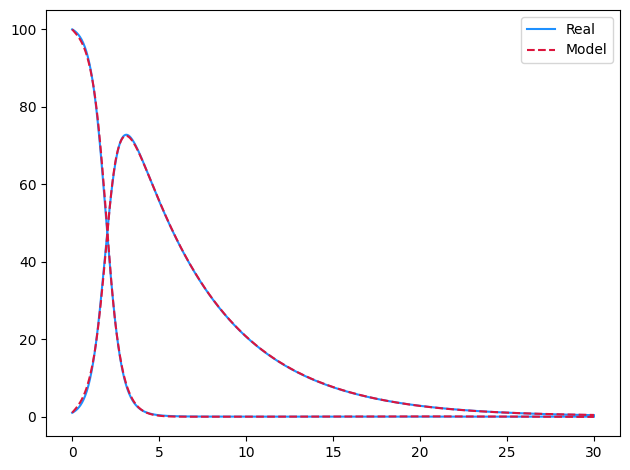

In [107]:
ts, ys, model = main()

Some notes on speed:
The hyperparameters for the above example haven't really been optimised. Try experimenting with them to see how much faster you can make this example run. There's lots of things you can try tweaking:

- The size of the neural network.
- The numerical solver.
- The step size controller, including both its step size and its tolerances.
- The length of the dataset. (Do you really need to use all of a time series every time?)
- Batch size, learning rate, choice of optimiser.
- ... etc.!

Some notes on being Markov:

- This example has assumed that the problem is Markov. Essentially, that the data `ys` is a complete observation of the system, and that we're not missing any channels. Note how the result of our model is evolving in data space. This is unlike e.g. an RNN, which has hidden state, and a linear map from hidden state to data.
- If we wanted we could generalise this to the non-Markov case: inside `NeuralODE`, project the initial condition into some high-dimensional latent space, do the ODE solve there, then take a linear map to get the output. See the [Latent ODE example](./latent_ode.ipynb) for an example doing this as part of a generative model; also see [Augmented Neural ODEs](https://arxiv.org/abs/1904.01681) for a short paper on it.